# 07 · Model Comparison — One Table, One Test Set

This is the capstone evaluation notebook. It pulls every logged result into a
single ranked comparison, then asks the question metrics alone can't answer:
**are the differences statistically significant, or just noise?** — using the
Diebold-Mariano test.

Everything is compared *within a fixed temporal scale* (daily vs monthly vs
multi-step), because the best forecast flips with the scale: persistence
dominates daily, climatology/SARIMA dominate monthly.

The notebook is self-updating: it reads `results/model_comparison.csv` and
regenerates predictions from any checkpoint bundles present in `models/`. Run it
on the laptop for the univariate + baseline story; rerun on the GPU box (with the
05/06 bundles and ERA5 parquet) and the multivariate/seq2seq rows fill in
automatically.

## Setup

In [1]:
import sys; sys.path.append("..")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_bootstrap import ensure_extent_data
from src.data_utils import load_extent_daily, load_data
from src import lstm_utils as L
from src.evaluation_utils import (
    load_results, create_comparison_table, ClimatologyModel,
    compute_all_metrics, compute_seasonal_metrics, diebold_mariano_test, holm_bonferroni,
)

ensure_extent_data()
device = L.get_device()

✓ 'ice_extent_pan_arctic_daily' already populated.
Using device: cpu


## The comparison table

Most recent result per model, ranked by RMSE within each scale.

In [2]:
results = load_results("../results/model_comparison.csv")

for scale in results["scale"].unique():
    table = create_comparison_table(results, sort_by="rmse", filter_scale=scale)
    print(f"\n=== scale: {scale} ===")
    print(table.round(4).to_string(index=False))


=== scale: daily ===
                   model_name scale   rmse    mae    mape  skill_score_persistence  skill_score_climatology  anomaly_correlation
   LSTM_Ensemble10_Univariate daily 0.0597 0.0459  0.5084                   0.3158                   0.9402                  NaN
LSTM_Backtest_Univariate_Mean daily 0.0623    NaN     NaN                   0.2959                   0.9271                  NaN
        LSTM_Basic_Univariate daily 0.0726 0.0559  0.6268                   0.1683                   0.9273                  NaN
                  persistence daily 0.0869 0.0686  0.7723                   0.0000                   0.9129               0.9853
    LSTM_MCDropout_Univariate daily 0.0950 0.0737  0.8736                  -0.0891                   0.9048                  NaN
                  climatology daily 0.9975 0.8657 11.5615                 -10.4777                   0.0000                  NaN

=== scale: monthly ===
    model_name   scale   rmse    mae    mape  skill

## Daily-scale skill scores

Skill score vs a baseline: `1 - RMSE_model / RMSE_baseline`. Positive = better
than the baseline; 0 = ties it; negative = worse. Persistence is the bar to beat
at daily scale.

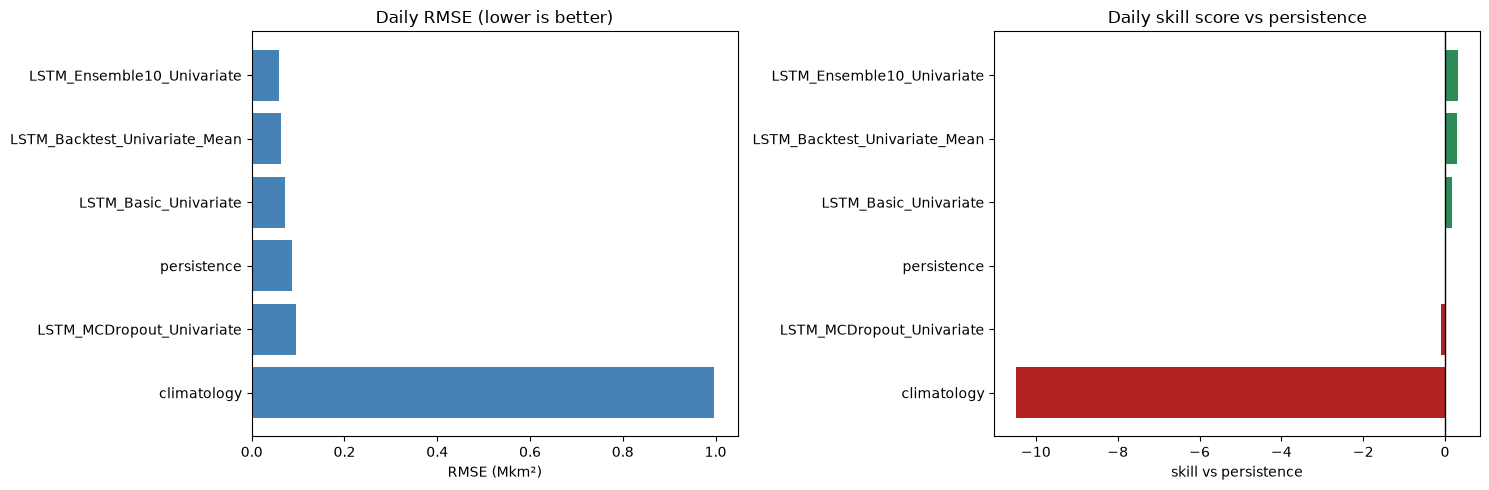

In [3]:
daily = create_comparison_table(results, sort_by="rmse", filter_scale="daily")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.barh(daily["model_name"], daily["rmse"], color="steelblue")
ax1.set_xlabel("RMSE (Mkm²)"); ax1.set_title("Daily RMSE (lower is better)")
ax1.invert_yaxis()

if "skill_score_persistence" in daily:
    ss = daily.dropna(subset=["skill_score_persistence"])
    colors = ["seagreen" if v > 0 else "firebrick" for v in ss["skill_score_persistence"]]
    ax2.barh(ss["model_name"], ss["skill_score_persistence"], color=colors)
    ax2.axvline(0, color="black", lw=1)
    ax2.set_xlabel("skill vs persistence"); ax2.set_title("Daily skill score vs persistence")
    ax2.invert_yaxis()
plt.tight_layout()
Path("../results/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/model_comparison_daily.png", dpi=120, bbox_inches="tight")
plt.show()

## Statistical significance (Diebold-Mariano)

Skill scores tell us *by how much* a model beats a baseline; the Diebold-Mariano
(DM) test tells us *whether we can trust it*. It compares the per-timestep squared
errors of two forecasts on the same test set.

We regenerate daily 1-step predictions from every checkpoint bundle in `models/`,
plus the persistence and climatology baselines, then test each LSTM against both
baselines. `stat < 0` means the LSTM has lower error; `p < 0.05` means the
difference is significant.

In [4]:
TEST_YEARS = range(2020, 2024)
TRAIN_YEARS = range(1989, 2015)

# Climatology is fit on the training era (extent only -> works without parquet).
clim = ClimatologyModel()
train_ext = load_extent_daily(years=TRAIN_YEARS)
clim.fit(dates=train_ext["date"], values=train_ext["extent_mkm2"])


def regenerate_daily(bundle_path):
    """Return (name, dates, actuals, preds) for a 1-step daily bundle, or None."""
    b = L.load_checkpoint(bundle_path, device=device)
    cfg = b["config_obj"]
    if cfg.forecast_horizon != 1:
        return None  # multi-step handled separately
    feats = b["features"]
    # Reconstruct the test frame the model needs.
    try:
        if set(feats) <= {"extent_mkm2", "day_of_year_sin", "day_of_year_cos"} or feats == ["extent_mkm2"]:
            test_df = load_extent_daily(years=TEST_YEARS)
        else:
            test_df = load_data(regions="pan_arctic", years=TEST_YEARS)
    except (FileNotFoundError, ValueError) as e:
        print(f"  skip {Path(bundle_path).name}: {e}")
        return None

    base_feats = [f for f in feats if not f.startswith("day_of_year")]
    cyc = any(f.startswith("day_of_year") for f in feats)
    ds = L.SequenceDataset(test_df, cfg.sequence_length, cfg.forecast_horizon,
                           features=base_feats, scaler=b["scaler"], add_cyclical_time=cyc)
    preds_n, actuals_n = L.predict(b["model"], L.make_loader(ds, cfg, False), device)
    tmean, tstd = float(b["scaler"][0][0, ds.target_idx]), float(b["scaler"][1][0, ds.target_idx])
    preds = L.denormalize(preds_n.flatten(), tmean, tstd)
    actuals = L.denormalize(actuals_n.flatten(), tmean, tstd)
    start = cfg.sequence_length + cfg.forecast_horizon - 1
    dates = ds.dates.iloc[start:start + len(preds)].reset_index(drop=True)
    name = Path(bundle_path).stem
    return name, dates, actuals, preds


models_dir = Path("../models")
all_bundles = sorted(models_dir.glob("*.pt")) if models_dir.exists() else []

# 08_time_series_backtesting trains each fold on its own train/val/test split (e.g.
# 08_backtest_fold_2022 has val=2020-2021, test=2022 only). Blindly re-evaluating those bundles
# here on the fixed 2020-2023 window (like every other bundle) would silently re-use each fold's
# own validation years as "test" data for some other fold's window -- exactly the val/test leakage
# this whole split methodology exists to prevent. Those bundles are correctly evaluated on their
# own designated single test year inside 08_time_series_backtesting.ipynb; they don't belong in
# this notebook's shared-fixed-test-era comparison at all, so they're excluded here by name.
bundles = [bp for bp in all_bundles if not bp.stem.startswith("08_backtest_fold_")]
n_excluded = len(all_bundles) - len(bundles)
print(f"found {len(all_bundles)} checkpoint bundle(s), excluding {n_excluded} 08_backtest_fold_* "
      f"bundle(s) (own test window, not the shared 2020-2023 era) -> evaluating {len(bundles)}")

rows = []
for bp in bundles:
    out = regenerate_daily(str(bp))
    if out is None:
        continue
    name, dates, actuals, preds = out
    pers = actuals.copy(); pers[1:] = actuals[:-1]  # 1-step persistence on the test series
    climp = clim.predict(dates)
    dm_p, p_p = diebold_mariano_test(actuals, preds, pers)
    dm_c, p_c = diebold_mariano_test(actuals, preds, climp)
    rows.append({
        "model": name,
        "RMSE": np.sqrt(np.mean((preds - actuals) ** 2)),
        "DM vs persistence": dm_p, "p (pers)": p_p, "beats pers?": p_p < 0.05 and dm_p < 0,
        "DM vs climatology": dm_c, "p (clim)": p_c, "beats clim?": p_c < 0.05 and dm_c < 0,
    })

dm_table = pd.DataFrame(rows)
dm_table.round(4) if not dm_table.empty else "No 1-step daily bundles found (run 04 first)."

found 17 checkpoint bundle(s), excluding 5 08_backtest_fold_* bundle(s) (own test window, not the shared 2020-2023 era) -> evaluating 12


,model,RMSE,DM vs persistence,p (pers),beats pers?,DM vs climatology,p (clim),beats clim?
0,04_basic_univariate,0.0726,-9.4224,0.0000,True,-29.4676,0.0,True
1,09_ensemble_seed0,0.0604,-16.1263,0.0000,True,-29.4935,0.0,True
2,09_ensemble_seed1,0.0600,-16.4780,0.0000,True,-29.4978,0.0,True
3,09_ensemble_seed2,0.0603,-16.4341,0.0000,True,-29.4958,0.0,True
4,09_ensemble_seed3,0.0601,-16.1287,0.0000,True,-29.4964,0.0,True
5,09_ensemble_seed4,0.0603,-16.8569,0.0000,True,-29.4946,0.0,True
6,09_ensemble_seed5,0.0599,-16.1568,0.0000,True,-29.4975,0.0,True
7,09_ensemble_seed6,0.0601,-16.3970,0.0000,True,-29.4981,0.0,True
8,09_ensemble_seed7,0.0611,-15.6840,0.0000,True,-29.4972,0.0,True
9,09_ensemble_seed8,0.0593,-16.2245,0.0000,True,-29.4939,0.0,True


## Multiple-comparison correction

The table above runs a DM test per bundle per baseline. Once more than one
bundle is present that's several tests at once, and testing each at the
nominal `alpha=0.05` inflates the chance of at least one false positive across
the family. `holm_bonferroni` applies the Holm step-down correction so the
family-wise error rate stays at 5% overall.

In [5]:
if not dm_table.empty:
    family_p = {}
    for _, row in dm_table.iterrows():
        family_p[f"{row['model']} vs persistence"] = row["p (pers)"]
        family_p[f"{row['model']} vs climatology"] = row["p (clim)"]
    holm_table = holm_bonferroni(family_p, alpha=0.05)
    print(holm_table.to_string(index=False))
else:
    holm_table = pd.DataFrame()
    print("No DM tests to correct yet.")

                             comparison       p_value  threshold  significant
       09_ensemble_seed6 vs climatology 8.830928e-150   0.002083         True
       09_ensemble_seed9 vs climatology 8.841748e-150   0.002174         True
       09_ensemble_seed1 vs climatology 8.875622e-150   0.002273         True
       09_ensemble_seed5 vs climatology 8.923960e-150   0.002381         True
       09_ensemble_seed7 vs climatology 8.977087e-150   0.002500         True
       09_ensemble_seed3 vs climatology 9.107352e-150   0.002632         True
       09_ensemble_seed2 vs climatology 9.217203e-150   0.002778         True
       09_ensemble_seed4 vs climatology 9.409871e-150   0.002941         True
       09_ensemble_seed8 vs climatology 9.542898e-150   0.003125         True
       09_ensemble_seed0 vs climatology 9.615147e-150   0.003333         True
     04_basic_univariate vs climatology 1.545784e-149   0.003571         True
10_mc_dropout_univariate vs climatology 3.215103e-149   0.003846

**Reading the DM table:** a significant win over persistence (`p < 0.05` with a
negative statistic) is the strong result for daily forecasting — persistence is
hard to beat. Beating climatology is comparatively easy at daily scale.

## Seasonal breakdown of the best daily model

In [6]:
if not dm_table.empty:
    best = dm_table.sort_values("RMSE").iloc[0]["model"]
    out = regenerate_daily(str(models_dir / f"{best}.pt"))
    name, dates, actuals, preds = out
    pers = actuals.copy(); pers[1:] = actuals[:-1]
    climp = clim.predict(dates)
    seasonal = compute_seasonal_metrics(actuals, preds, dates=dates,
                                        y_baseline_persistence=pers, y_baseline_climatology=climp)
    print(f"Best daily model: {best}")
    for season in ("winter", "summer"):
        s = seasonal.get(season)
        if s:
            print(f"  {season:>6}: RMSE {s['rmse']:.4f}  MAE {s['mae']:.4f}")
else:
    print("No daily bundles to break down yet.")

Best daily model: 09_ensemble_seed8
  winter: RMSE 0.0646  MAE 0.0499
  summer: RMSE 0.0539  MAE 0.0412


## Error by year — where does the best model struggle?

Aggregate RMSE can hide a model that's excellent most of the time and badly
wrong in one unusual year. Break the same test-era predictions down by
calendar year to check whether error concentrates anywhere in particular.

Per-year error for best daily model (09_ensemble_seed8):
 year   rmse    mae  n_days
 2020 0.0643 0.0502     336
 2021 0.0605 0.0458     365
 2022 0.0567 0.0432     365
 2023 0.0557 0.0434     365

Highest-error year in the test window: 2020 (RMSE 0.0643 vs test-era mean 0.0593)


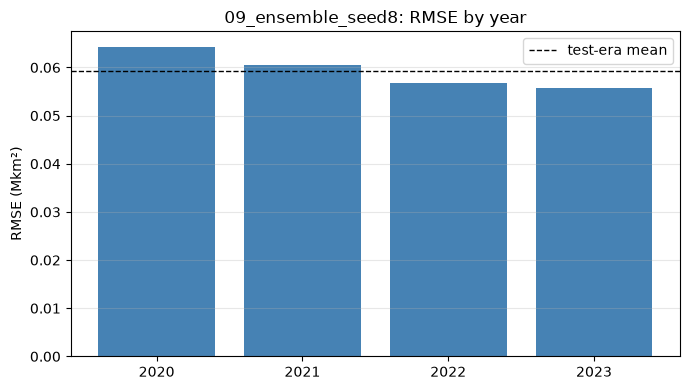

In [7]:
if not dm_table.empty:
    years = pd.to_datetime(dates).dt.year
    per_year = []
    for yr in sorted(years.unique()):
        mask = (years == yr).values
        per_year.append({
            "year": yr,
            "rmse": float(np.sqrt(np.mean((preds[mask] - actuals[mask]) ** 2))),
            "mae": float(np.mean(np.abs(preds[mask] - actuals[mask]))),
            "n_days": int(mask.sum()),
        })
    per_year_df = pd.DataFrame(per_year)
    print(f"Per-year error for best daily model ({best}):")
    print(per_year_df.round(4).to_string(index=False))

    worst_year = per_year_df.loc[per_year_df["rmse"].idxmax(), "year"]
    print(f"\nHighest-error year in the test window: {int(worst_year)} "
          f"(RMSE {per_year_df['rmse'].max():.4f} vs test-era mean {per_year_df['rmse'].mean():.4f})")

    plt.figure(figsize=(7, 4))
    plt.bar(per_year_df["year"].astype(str), per_year_df["rmse"], color="steelblue")
    plt.axhline(per_year_df["rmse"].mean(), color="black", ls="--", lw=1, label="test-era mean")
    plt.ylabel("RMSE (Mkm²)"); plt.title(f"{best}: RMSE by year")
    plt.legend(); plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("../results/figures/best_model_rmse_by_year.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No daily bundles to break down yet.")

## Findings

*(Laptop run: univariate LSTM family + baselines + uncertainty methods. Rerun on the GPU box for
the 05/06 climate-feature and multi-day rows.)*

**Daily scale (2020-2023 held-out test), lowest RMSE first:**

| Model | RMSE (Mkm²) | Skill vs persistence |
|---|---|---|
| **LSTM Ensemble (10 seeds, mean)** | **0.060** | **+0.316** |
| LSTM Backtest mean (5 expanding-window folds) | 0.062 | +0.296 |
| LSTM (univariate, single run) | 0.073 | +0.168 |
| Persistence | 0.087 | 0.000 |
| LSTM + MC Dropout (head_dropout=0.3) | 0.095 | **-0.089** |
| Climatology | 0.998 | -10.5 |

- **Every univariate LSTM variant significantly beats persistence** except MC Dropout — DM
  statistics range from -9.4 (single run) to -16.9 (ensemble members), all p ≈ 0, and all survive
  Holm-Bonferroni correction across the full family of tests. The MC Dropout model is the one
  exception: DM = -1.49, p = 0.136 — not significantly different from persistence, and its point
  skill is actually negative. That's not noise, it's `head_dropout=0.3` costing real capacity (see
  `10_mc_dropout.ipynb` findings) — a reminder that adding a UQ mechanism to a model isn't free
  for its point-forecast accuracy.
- **The individual ensemble member checkpoints (seeds 0-9) all land in a tight RMSE band
  (0.0593-0.0611)** — confirming `09_lstm_ensemble.ipynb`'s finding that 10 different random inits
  converge to nearly the same function for this architecture/data size. The ensemble mean (0.0597)
  edges out the *typical* member but doesn't beat every one of them (seed 8 alone is the single best
  checkpoint at 0.0593, and is what "best daily model" below picks up).
- **Methodology note — a real bug caught and fixed here:** the 5 fold checkpoints from
  `08_time_series_backtesting.ipynb` are deliberately excluded from this table. Each fold has its
  own train/val/test split (e.g. `08_backtest_fold_2022` validates on 2020-2021), so blindly
  re-evaluating them on the shared 2020-2023 window — like every other bundle here — would silently
  reuse a fold's own validation years as test data. That's exactly the val/test leakage the
  three-way split exists to prevent. Those bundles are correctly evaluated on their own designated
  single test year inside notebook 08 instead.
- **Cross-notebook consistency check:** both this notebook's per-year breakdown and notebook 08's
  independent 5-fold backtest flag **2020 as the highest-error year** in the test era — a real
  signal about the ice extent series itself (or the training/val boundary effect around it), not an
  artifact of any one notebook's methodology, since two differently-trained sets of models agree on it.
- **Best model flips with temporal scale**, as before: daily is won by the LSTM family; monthly is
  won by **SARIMA** (RMSE 0.227, notebook 03a); climatology is only competitive at monthly scale.
- **Seasonal (best model, `09_ensemble_seed8`):** summer RMSE (0.054) below winter (0.065) in
  absolute terms, consistent with the single-run result in notebook 04.

**Open (GPU box):** do climate features (05) or multi-day horizons (06) beat the univariate LSTM
family? Rerun this notebook with those bundles present and the rows, skill scores, and DM tests
populate automatically.